In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:

nx, ny = 8, 8

nx_reduce, ny_reduce = 6, 6

Nx, Ny = 2**nx, 2**ny

Nx_reduce, Ny_reduce = 2**nx_reduce, 2**ny_reduce

Lx, Ly = 50.0, 50.0

dx, dy = Lx / Nx, Ly / Ny

x = (np.arange(Nx) - Nx//2) * dx
y = (np.arange(Ny) - Ny//2) * dy

X, Y = np.meshgrid(x, y, indexing='ij')


dt = 0.01

t = 60

steps = int(np.round(t / dt))


kx = 2.0 * np.pi * np.fft.fftfreq(Nx, d=dx)
ky = 2.0 * np.pi * np.fft.fftfreq(Ny, d=dy)
KX, KY = np.meshgrid(kx, ky, indexing='ij')
K2 = KX**2 + KY**2


L_half = np.exp(-1j * K2 * dt/4)        

In [ ]:

def initial_state_dark_soliton(x, y, Ly):

    g = 1.0

    rho0 = 1.0

    xi = 1.0 / np.sqrt(g * rho0)

    x0 = 0.0


    a = 0.3

    m = 1

    ky_wobble = 2.0 * np.pi * m / Ly

    x0y = x0 + a * np.cos(ky_wobble * Y)


    psi = np.sqrt(rho0) * np.tanh((X - x0y) / xi)
    psi = psi.astype(np.complex128)

    phase_amp = 0.03
    psi *= np.exp(1j * phase_amp * np.cos(ky_wobble * Y))

    return psi, g, rho0

In [ ]:

def discrete_norm(psi):

    return np.sqrt(np.sum(np.abs(psi)**2))


def renormalize_problem(psi, g_val, rho0_val):

    norm = discrete_norm(psi)
    psi = psi / norm
    g_val = g_val * norm**2
    rho0_val = rho0_val / norm**2
    return psi, g_val, rho0_val, norm



In [ ]:

def ssfm(psi, g, rho0, dt, L_half):
    psi = np.fft.ifft2(np.fft.fft2(psi) * L_half)        
    psi = psi*np.exp(-g * 1j * (np.abs(psi)**2 - rho0) * dt)  
    psi = np.fft.ifft2(np.fft.fft2(psi) * L_half)         

    return psi

In [ ]:

def filtering_2d(modes, Nx, Ny, Nx_reduce, Ny_reduce):

    halfx = Nx_reduce // 2
    halfy = Ny_reduce // 2
    filtered_modes = np.zeros((Nx, Ny), dtype=complex)
    filtered_modes[:halfx, :halfy]   = modes[:halfx, :halfy]
    filtered_modes[:halfx, -halfy:]  = modes[:halfx, -halfy:]
    filtered_modes[-halfx:, :halfy]  = modes[-halfx:, :halfy]
    filtered_modes[-halfx:, -halfy:] = modes[-halfx:, -halfy:]

    return filtered_modes

In [ ]:

def filtered_qssfm(psi, g, rho0, dt, L_half, Nx, Ny, Nx_reduce, Ny_reduce):
    psi = np.fft.fft2(psi) * L_half                                  
    modes = filtering_2d(psi, Nx, Ny, Nx_reduce, Ny_reduce)
    psi = np.fft.ifft2(psi)

    nonlinear_term = np.fft.ifft2(modes)
    psi *= np.exp(-g* 1j * (np.abs(nonlinear_term)**2 - rho0) * dt)       

    psi = np.fft.fft2(psi) * L_half                                
    psi = np.fft.ifft2(psi)
    return psi

In [ ]:

def percent_k(psi_ssfm, psi_qssfm, Nx, Ny, Nx_reduce, Ny_reduce):
    a = np.fft.fft2(psi_ssfm)
    b = np.fft.fft2(psi_qssfm) 
    c = np.fft.fft2(psi_qssfm) 
    b = filtering_2d(b, Nx, Ny, Nx_reduce, Ny_reduce)
    eta = np.sum(np.abs(b)**2) / np.sum(np.abs(a)**2)

    c_shift = np.roll(c, shift=a.shape[0]//2, axis=0)
    c_shift = np.roll(c_shift, shift=a.shape[1]//2, axis=1)
    b_shift = np.roll(b, shift=a.shape[0]//2, axis=0)
    b_shift = np.roll(b_shift, shift=a.shape[1]//2, axis=1)
    return eta, np.abs(c_shift), np.abs(b_shift)

In [ ]:

def error(psi, psi_exact):
    rho_exact = np.abs(psi_exact)**2
    rho1 = np.abs(psi)**2
    error = np.sqrt(np.sum((rho1 - rho_exact)**2) / np.sum(rho_exact**2))
    return error

In [ ]:

if __name__ == "__main__":

    show_t = [0, 50, 60]
    psi0_initial, g_initial, rho0_initial = initial_state_dark_soliton(X, Y, Ly)
    psi0, g, rho0, norm = renormalize_problem(psi0_initial, g_initial, rho0_initial)
    psi1 = np.copy(psi0)
    

    psi0density_history = [np.abs(psi0)**2*(norm**2)]                   
    psi1density_history = [np.abs(psi1)**2*(norm**2)]                                     
    times = [0]                                                        
    error_history = [error(psi1*norm, psi0*norm)]                        
    eta_term, k_term, k_keep_term = percent_k(psi0, psi1, Nx, Ny, Nx_reduce, Ny_reduce)
    eta = [eta_term]     
    k = [k_term]  
    k_keep = [k_keep_term]     

    for i in range(steps):
        psi0 = ssfm(psi0, g, rho0, dt, L_half)
        psi1 = filtered_qssfm(psi1, g, rho0, dt, L_half, Nx, Ny, Nx_reduce, Ny_reduce)
        eta_term, k_term, k_keep_term = percent_k(psi0, psi1, Nx, Ny, Nx_reduce, Ny_reduce)

        times.append((i + 1) * dt)                  
        eta.append(eta_term)
        error_history.append(error(psi1*norm, psi0*norm)) 

        if (i+1)*dt in show_t:
            psi0density_history.append(np.abs(psi0)**2*(norm**2))  
            psi1density_history.append(np.abs(psi1)**2*(norm**2))   
            k.append(k_term)
            k_keep.append(k_keep_term)
    

In [11]:
np.savez(f"2d-instability.npz",    
        times=show_t,
        psi_ssfm=psi0density_history,
        psi_filtered_qssfm=psi1density_history,
        k = k,
        k_keep = k_keep
        )      
np.savez(f"2d-instability_error.npz",    
        times = times,
        rel_l2_err=error_history,
        eta = eta
        )  

165.77670706840075


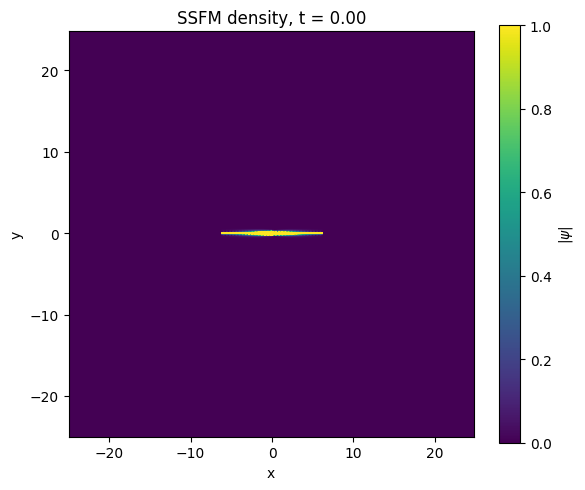

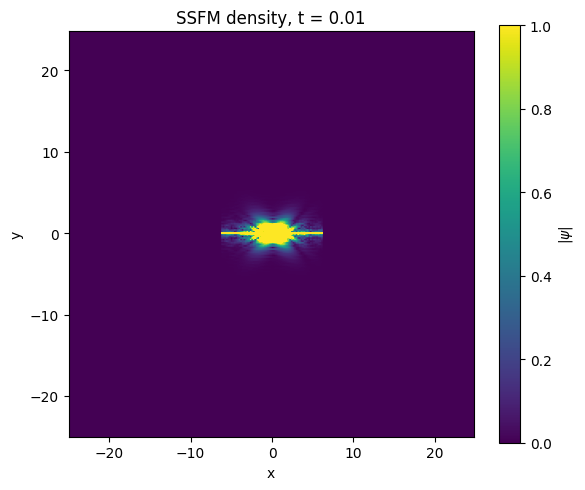

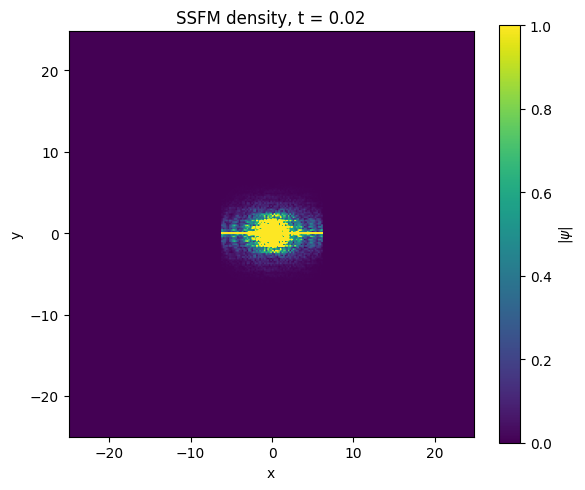

In [12]:
for t in range(len(show_t)):
    plt.figure(figsize=(6, 5))
    plt.imshow(
        k_keep[t].T,
        extent=[x.min(), x.max(), y.min(), y.max()],
        origin="lower",
        aspect="equal",
        cmap="viridis",
        vmin=0,
        vmax=1
    )
    plt.xlabel("x")
    plt.ylabel("y")
    plt.title(f"SSFM density, t = {times[t]:.2f}")
    plt.colorbar(label=r"$|\psi|$")
    plt.tight_layout()
    #plt.savefig(f"ssfm_density_2d_t={t}.png", dpi=300, bbox_inches="tight")
    #plt.show()
print(np.max(k))

165.77670706840075


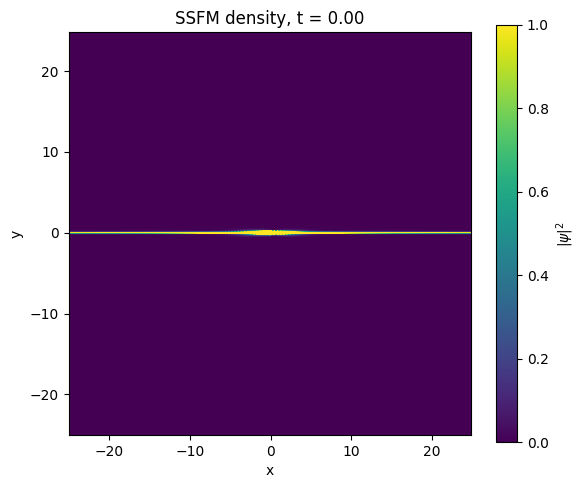

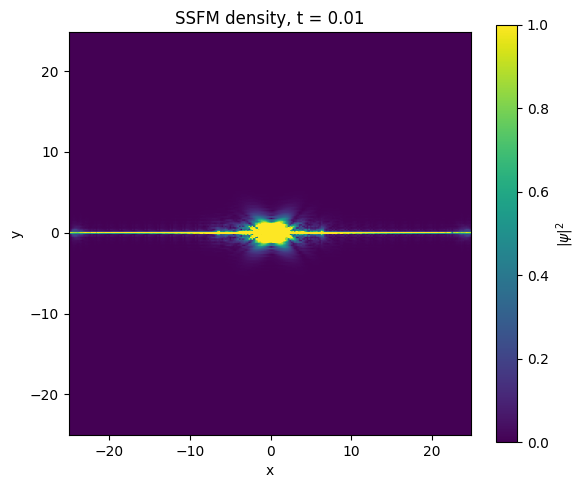

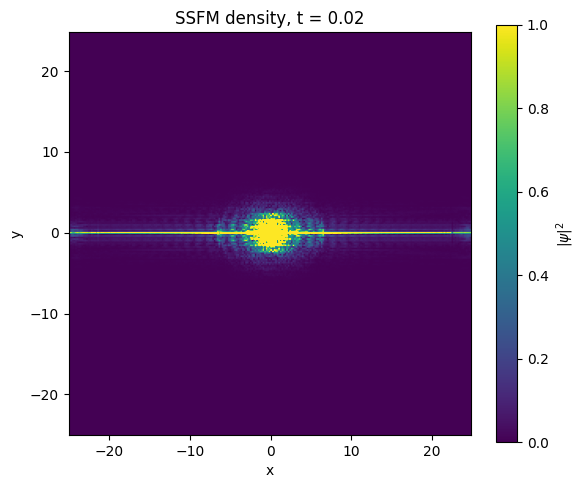

In [13]:
for t in range(len(show_t)):
    plt.figure(figsize=(6, 5))
    plt.imshow(
        k[t].T,
        extent=[x.min(), x.max(), y.min(), y.max()],
        origin="lower",
        aspect="equal",
        cmap="viridis",
        vmin=0,
        vmax=1
    )
    plt.xlabel("x")
    plt.ylabel("y")
    plt.title(f"SSFM density, t = {times[t]:.2f}")
    plt.colorbar(label=r"$|\psi|^2$")
    plt.tight_layout()
    #plt.savefig(f"ssfm_density_2d_t={t}.png", dpi=300, bbox_inches="tight")
    #plt.show()
print(np.max(k))

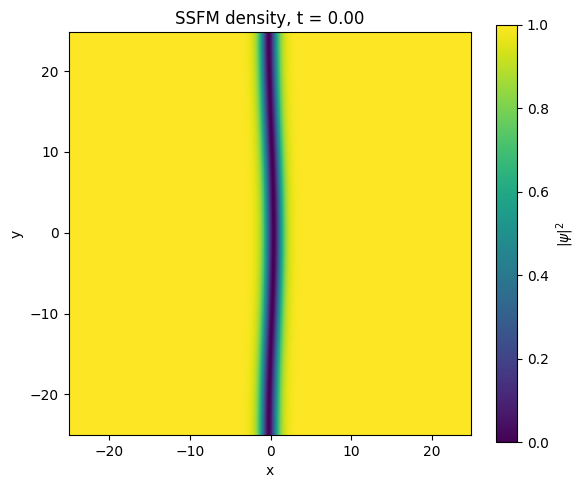

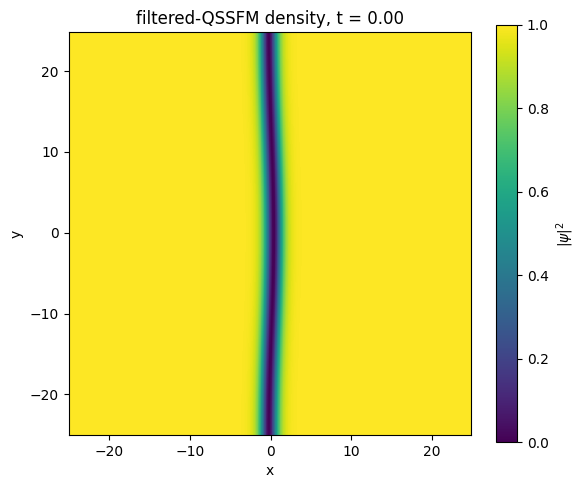

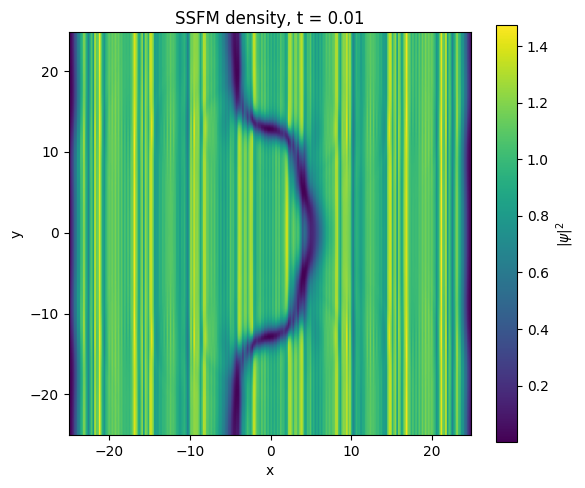

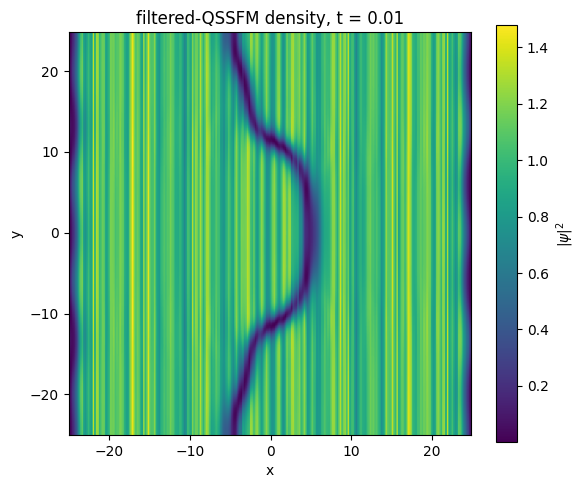

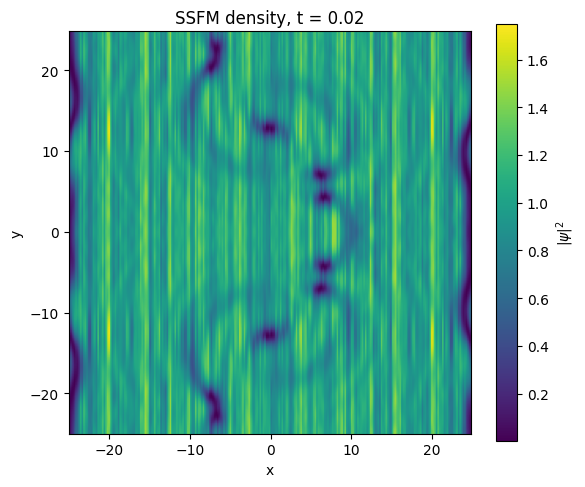

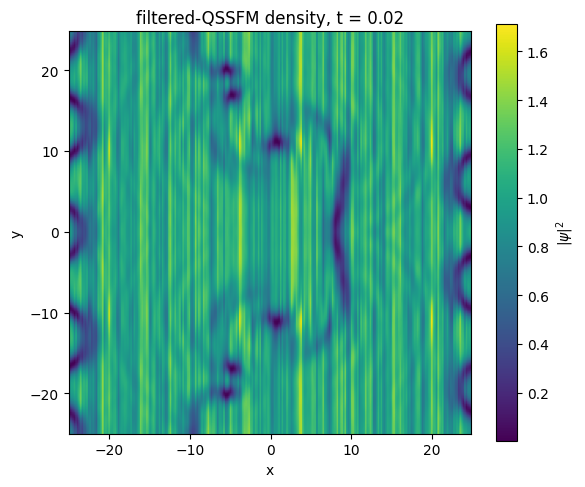

In [14]:
for t in range(len(show_t)):
    plt.figure(figsize=(6, 5))
    plt.imshow(
        psi0density_history[t].T,
        extent=[x.min(), x.max(), y.min(), y.max()],
        origin="lower",
        aspect="equal",
        cmap="viridis"
    )
    plt.xlabel("x")
    plt.ylabel("y")
    plt.title(f"SSFM density, t = {times[t]:.2f}")
    plt.colorbar(label=r"$|\psi|^2$")
    plt.tight_layout()
    #plt.savefig(f"ssfm_density_2d_t={t}.png", dpi=300, bbox_inches="tight")
    #plt.show()

    plt.figure(figsize=(6, 5))
    plt.imshow(
        psi1density_history[t].T,
        extent=[x.min(), x.max(), y.min(), y.max()],
        origin="lower",
        aspect="equal",
        cmap="viridis"
    )
    plt.xlabel("x")
    plt.ylabel("y")
    plt.title(f"filtered-QSSFM density, t = {times[t]:.2f}")
    plt.colorbar(label=r"$|\psi|^2$")
    plt.tight_layout()
    #plt.savefig(f"filtered_qssfm_density_2d_t={t}.png", dpi=300, bbox_inches="tight")
    #plt.show()


In [15]:
print(eta[1])

0.9937507233008522


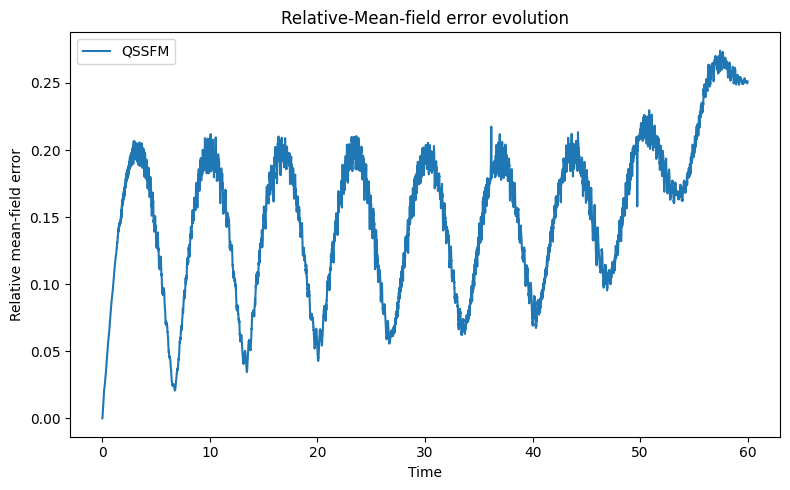

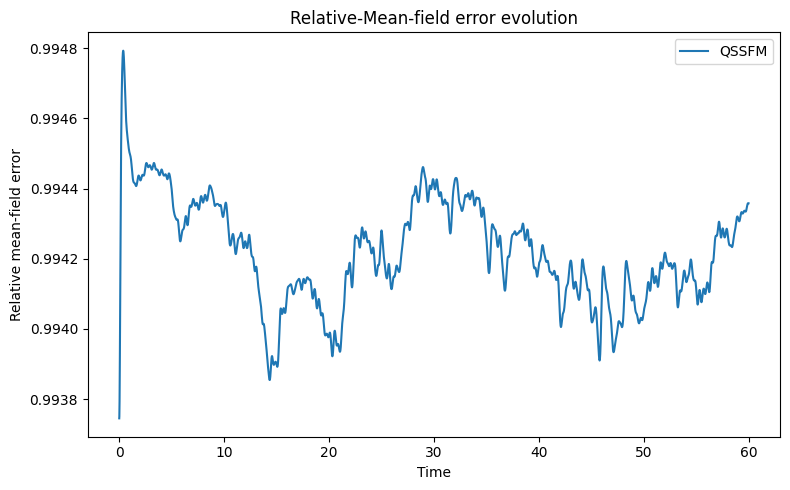

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(times, error_history, label='QSSFM')

plt.xlabel('Time')
plt.ylabel('Relative mean-field error')
plt.legend()
plt.title('Relative-Mean-field error evolution')
plt.tight_layout()
#plt.savefig("mean_field_error.pdf", dpi=300)
plt.show()

plt.figure(figsize=(8,5))
plt.plot(times, eta, label='QSSFM')

plt.xlabel('Time')
plt.ylabel('Relative mean-field error')

plt.legend()
plt.title('Relative-Mean-field error evolution')
plt.tight_layout()
#plt.savefig("mean_field_error.pdf", dpi=300)
plt.show()